<a href="https://colab.research.google.com/github/vasusharma7/Machine-Learning/blob/master/pretrain_gpt_2_kv_cache.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [106]:
import os
# Set memory management configuration before further torch operations
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

This code is heavily inspired from [Sebastian Raschka](https://x.com/rasbt)'s excellent book, "[Build a Large Language Model (From Scratch)](https://www.manning.com/books/build-a-large-language-model-from-scratch)" and some of the edits from [@virattt](https://www.x.com/virattt) (from twitter).


In [107]:
!pip install financial-datasets --quiet
!pip install tiktoken --quiet

### 1. Setup the config

In [108]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

### 2. Implement LayerNorm

In [109]:
import torch
from torch import nn

class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    normalized_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * normalized_x + self.shift

### 5. Implement feed forward network with GELU activations

In [110]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [111]:
# Implement feed-forward neural network
class FeedForward(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(config["emb_dim"], 4 * config["emb_dim"]),
        GELU(),
        nn.Linear(4 * config["emb_dim"], config["emb_dim"]),
    )

  def forward(self, x):
    return self.layers(x)

### 6. Implement multi-head attention

In [112]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self._out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )

  def forward(self, x, past_key_value=None):
    batch_size, num_tokens, _ = x.shape

    queries = self.W_query(x) # (B, T, D)
    keys = self.W_key(x)      # (B, T, D)
    values = self.W_value(x)  # (B, T, D)

    # Reshape for multi-head
    queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
    keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
    values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

    if past_key_value is not None:
        prev_k, prev_v = past_key_value
        keys = torch.cat((prev_k, keys), dim=2)
        values = torch.cat((prev_v, values), dim=2)

    present_key_value = (keys, values)

    # Calculate attention
    attn_scores = (queries @ keys.transpose(-2, -1)) / (self.head_dim ** 0.5)

    # Causal mask application
    # During decoding (num_tokens=1), we attend to everything in the past cache
    T_total = keys.size(2)
    mask = self.mask.bool()[:num_tokens, :T_total]
    # Adjust mask if we are using cache (offset the query index)
    if past_key_value is not None:
        # Current token is at index T_total - 1
        # In KV-mode, we usually only have 1 query token.
        # We mask based on its absolute position in the sequence
        curr_pos = T_total - num_tokens
        mask = self.mask.bool()[curr_pos : T_total, : T_total]

    attn_scores.masked_fill_(mask, -float('inf'))
    attn_weights = torch.softmax(attn_scores, dim=-1)
    attn_weights = self.dropout(attn_weights)

    context_vectors = (attn_weights @ values).transpose(1, 2)
    context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.d_out)
    return self._out_proj(context_vectors), present_key_value

### 7. Implement the Transformer block

In [113]:
class TransformerBlock(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.attention = MultiHeadAttention(
        d_in=config["emb_dim"],
        d_out=config["emb_dim"],
        context_length=config["context_length"],
        dropout=config["drop_rate"],
        num_heads=config["n_heads"],
        qkv_bias=config["qkv_bias"]
    )
    self.ff = FeedForward(config)
    self.norm1 = LayerNorm(config["emb_dim"])
    self.norm2 = LayerNorm(config["emb_dim"])
    self.drop_shortcut = nn.Dropout(config["drop_rate"])

  def forward(self, x, past_key_value=None):
    # Attention path
    attn_out, present_kv = self.attention(self.norm1(x), past_key_value=past_key_value)
    x = x + self.drop_shortcut(attn_out)

    # Feedforward path
    x = x + self.drop_shortcut(self.ff(self.norm2(x)))
    return x, present_kv

### 8. Implement the GPT model

In [114]:
class GPTModel(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.token_embedding = nn.Embedding(config["vocab_size"], config["emb_dim"])
    self.positional_embedding = nn.Embedding(config["context_length"], config["emb_dim"])
    self.drop_embedding = nn.Dropout(config["drop_rate"])
    self.transformer_blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config["n_layers"])])
    self.final_norm = LayerNorm(config["emb_dim"])
    self.out_head = nn.Linear(config["emb_dim"], config["vocab_size"], bias=False)

  def forward(self, in_idx, past_key_values=None):
    batch_size, sequence_length = in_idx.shape

    # Position offset calculation for KV-cache
    start_pos = 0
    if past_key_values is not None:
        start_pos = past_key_values[0][0].size(2)

    token_embeddings = self.token_embedding(in_idx)
    pos_indices = torch.arange(start_pos, start_pos + sequence_length, device=in_idx.device)
    positional_embeddings = self.positional_embedding(pos_indices)

    x = self.drop_embedding(token_embeddings + positional_embeddings)

    present_key_values = []
    for i, block in enumerate(self.transformer_blocks):
        layer_past = past_key_values[i] if past_key_values is not None else None
        x, present_kv = block(x, past_key_value=layer_past)
        present_key_values.append(present_kv)

    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits, present_key_values

In [115]:
torch.manual_seed(123)
# Determine the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GPTModel(GPT_CONFIG_124M)
# Move model to the correct device
model.to(device)

GPTModel(
  (token_embedding): Embedding(50257, 768)
  (positional_embedding): Embedding(1024, 768)
  (drop_embedding): Dropout(p=0.1, inplace=False)
  (transformer_blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (_out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
  )
  (final_norm): LayerNorm()
  (out_head): 

### 9. Generate some text

In [116]:
def text_to_token_ids(text, tokenizer):
    # Encodes a string into a tensor of token IDs
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    # .unsqueeze(0) adds the batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    # Decodes a tensor of token IDs back into a string
    flat = token_ids.squeeze(0) # Remove batch dimension
    return tokenizer.decode(flat.tolist())

def generate_text_with_kv_cache(model, idx, max_new_tokens, context_size):
    # Prefill phase
    past_key_values = None

    # We only take the last 'context_size' tokens if prompt is too long
    idx_cond = idx[:, -context_size:]

    for i in range(max_new_tokens):
        with torch.no_grad():
            # On the first iteration, we pass the full prompt
            # On subsequent iterations, we only pass the single newest token
            input_idx = idx_cond if i == 0 else idx_cond[:, -1:]
            logits, past_key_values = model(input_idx, past_key_values=past_key_values)

            # Take logits of the last token
            logits = logits[:, -1, :]
            probas = torch.softmax(logits, dim=-1)
            idx_next = torch.argmax(probas, dim=-1, keepdim=True)

            # Append to sequence
            idx_cond = torch.cat((idx_cond, idx_next), dim=1)
            idx = torch.cat((idx, idx_next), dim=1)

            # Ensure we don't exceed context window
            if idx_cond.size(1) > context_size:
                # Note: Simple KV cache truncation is complex; here we just trim idx_cond
                # for the sake of basic implementation.
                idx_cond = idx_cond[:, -context_size:]

    return idx

### 10. Create tokenizer

In [117]:
import tiktoken

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Using the KV-cached generation function
token_ids = generate_text_with_kv_cache(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer).to(device),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you Aeiman flaws Palin Gohanousse immensely CBO phenomenafigured


### 11. Create data loader

In [118]:
import torch
from torch.utils.data import Dataset, DataLoader

 # Create a data loader
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)

        for i in range(0, len(token_ids) - max_length, stride):
            # The input chunk
            input_chunk = token_ids[i:i + max_length]
            # The target chunk is the input chunk, offset by 1 character
            target_chunk = token_ids[i + 1: i + max_length + 1]

            # Append chunk to list of chunks
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [119]:
# Updated to ensure max_length matches model capabilities
def create_dataloader_v1(txt, batch_size=4, max_length=1024, stride=512, shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )
    return dataloader

In [120]:
import gc
# Forcefully clear GPU memory
if 'model' in locals():
    del model
if 'optimizer' in locals():
    del optimizer

gc.collect()
torch.cuda.empty_cache()
print("GPU Memory cleared.")

GPU Memory cleared.


In [121]:
import gc
import torch

# Thorough cleanup to free up the 14GB VRAM
if 'model' in locals():
    del model
if 'optimizer' in locals():
    del optimizer
if 'train_loader' in locals():
    del train_loader
if 'val_loader' in locals():
    del val_loader

gc.collect()
torch.cuda.empty_cache()
print("GPU Memory cleared and fragmentation config set.")

GPU Memory cleared and fragmentation config set.


### 12. Download our training text

In [122]:
# # convert texts to text_data by joining all of the text
# import csv
# texts = ""
# with open("./next_word_predictor.txt") as file:
#   texts = file.read()

# text_data = " ".join(texts)

In [123]:
# total_characters = len(text_data)
# total_tokens = len(tokenizer.encode(text_data))
# print(f"Total characters: {total_characters}")
# print(f"Total tokens: {total_tokens}")

In [124]:
tickers = [
    "AAPL",
    "NVDA",
    "MSFT",
]

years = [2023]

texts = []

In [125]:
from financial_datasets.parser import FilingParser
import time

parser = FilingParser()

for ticker in tickers:
  for year in years:
    print(f"Fetching 10K for {ticker} in {year}")
    ten_k = parser.get_10K_items(
      ticker=ticker,
      year=year,
      item_names=['Item 1', 'Item 7']
    )

    text = " ".join([item for item in ten_k])
    texts.append(text)

    # Prevent rate limiting from SEC
    time.sleep(1)

Fetching 10K for AAPL in 2023
Fetching 10K for NVDA in 2023
Fetching 10K for MSFT in 2023


In [126]:
# convert texts to text_data by joining all of the text
text_data = " ".join(texts)

In [127]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print(f"Total characters: {total_characters}")
print(f"Total tokens: {total_tokens}")

Total characters: 254999
Total tokens: 49204


### 13. Create training / validation data

In [128]:
train_ratio = 0.80 # 80% of data will be training, 20% will be validation
split_index = int(train_ratio * len(text_data))
train_data = text_data[:split_index]
val_data = text_data[split_index:]

In [129]:
torch.manual_seed(123)

# Further reduced max_length and batch_size to 1 for stability
train_loader = create_dataloader_v1(
    train_data,
    batch_size=1,
    max_length=128,
    stride=128,
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=1,
    max_length=128,
    stride=128,
    drop_last=False,
    shuffle=False,
    num_workers=0,
)

### 14. Implement loss functions


In [130]:
def calc_loss_batch(input_batch, target_batch, model, device):
  """
  Calculates the loss for a single batch.
  """
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)

  # Run the model - updated to unpack the tuple (logits, past_key_values)
  logits, _ = model(input_batch)

  # Calculate the loss
  loss = torch.nn.functional.cross_entropy(
      logits.flatten(0, 1),
      target_batch.flatten(),
  )
  return loss

In [131]:
# Optional for computing loss of entire Network
def calc_loss_loader(data_loader, model, device, num_batches=None):
  """
  Calculates the loss for all batches in a data loader.
  """
  total_loss = 0
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))

  for index, (input_batch, target_batch) in enumerate(data_loader):
    if index < num_batches:
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      total_loss += loss.item()
    else:
      break
  return total_loss / num_batches # Return the average across all batches

In [133]:
# Test out the loss function
# Optional for computing loss of entire Network ( without batches )
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-instantiate model for the test since previous ones were cleared
model = GPTModel(GPT_CONFIG_124M).to(device)

with torch.no_grad():
  train_loss = calc_loss_loader(train_loader, model, device)
  val_loss = calc_loss_loader(val_loader, model, device)

print(f"Train loss: {train_loss}")
print(f"Val loss: {val_loss}")

Train loss: 11.001257099603352
Val loss: 11.00464082066017


### 15. Implement training functions

In [135]:
# Optional for computing loss of entire Network ( with batches and average )
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  """
  Evaluates the model, giving estimate of model's training progress.
  """
  # Put the model in evaluation mode
  model.eval()
  with torch.no_grad():
      train_loss = calc_loss_loader(
          train_loader, model, device, num_batches=eval_iter
      )
      val_loss = calc_loss_loader(
          val_loader, model, device, num_batches=eval_iter
      )
  # Put the model back in training mode
  model.train()
  return train_loss, val_loss

In [136]:
def generate_and_print_sample(model, tokenizer, device, start_context):
  """
  Generates a sample text using the model.
  """
  # Put the model in evaluation mode
  model.eval()
  context_size = model.positional_embedding.weight.shape[0]
  encoded = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
      # Updated to use the new KV-cached generation function
      token_ids = generate_text_with_kv_cache(
          model=model, idx=encoded,
          max_new_tokens=50, context_size=context_size
      )
      decoded_text = token_ids_to_text(token_ids, tokenizer)
      print(decoded_text.replace("\n", " "))  # Compact print format
  # Put the model back in training mode
  model.train()

In [137]:
def train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq,
    eval_iter,
    start_context,
    tokenizer,
):
  """
  Trains the model.
  """
  # Initialize variables
  train_losses, val_losses, track_tokens_seen = [], [], []
  tokens_seen, global_step = 0, -1

  # The main training loop
  for epoch in range(num_epochs):
    # Put model in training mode
    model.train()

    # Iterate through batches
    for input_batch, target_batch in train_loader:
      # Reset loss gradients from previous epoch
      optimizer.zero_grad()

      # Calculate loss for batch
      loss = calc_loss_batch(input_batch, target_batch, model, device)

      # Calculate loss gradients using backprop
      loss.backward()

      # Update model weights using loss gradients
      optimizer.step()

      # Update global variables
      tokens_seen += input_batch.numel()
      global_step += 1

      # Evaluation step (optional)
      if global_step % eval_freq == 0:
        # Evaluate the model
        train_loss, val_loss = evaluate_model(
            model, train_loader, val_loader, device, eval_iter
        )
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        # print(f"Ep {epoch+1} (Step {global_step:06d}): "
        #       f"Train loss {train_loss:.3f}, "
        #       f"Val loss {val_loss:.3f}"
        # )

    generate_and_print_sample(
        model, tokenizer, device, start_context
    )
  return train_losses, val_losses, track_tokens_seen


### 16. Train the model

In [134]:
import time
import gc

# Final memory cleanup before training to ensure max VRAM availability
if 'model' in locals(): del model
if 'optimizer' in locals(): del optimizer
gc.collect()
torch.cuda.empty_cache()

torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate fresh model after memory clear
model = GPTModel(GPT_CONFIG_124M)
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004,
    weight_decay=0.1,
)

num_epochs = 2 # Reduced epochs for a quicker memory-safe test

start_time = time.time()
train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=1,
    start_context="Fiscal year 2023 included",
    tokenizer=tokenizer,
)
end_time = time.time()
print(f"Training time: {end_time - start_time}")

Fiscal year 2023 included to our our our our our to our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our
Fiscal year 2023 included, and the Company’s, and the Company’s, and the Company’s, and the Company’s, and the Company’s, and the Company’s, and the Company’s,
Training time: 72.36968231201172


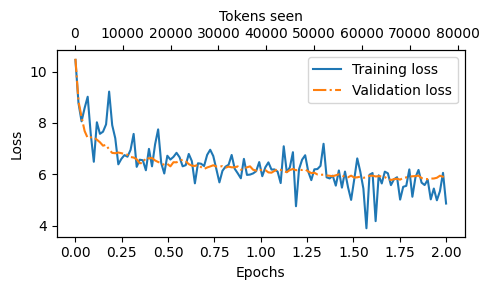

In [138]:
import matplotlib.pyplot as plt

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [139]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [140]:
total_params_gpt2 = (
    total_params - sum(p.numel()
    for p in model.out_head.parameters())
)
print(f"Number of trainable parameters "
      f"considering weight tying: {total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying: 124,412,160


### 17. Add temperature (randomness) parameter

In [141]:
# Determine the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Put model in eval mode on CPU/GPU since inference does not require compute
model.to(device)
model.eval()

GPTModel(
  (token_embedding): Embedding(50257, 768)
  (positional_embedding): Embedding(1024, 768)
  (drop_embedding): Dropout(p=0.1, inplace=False)
  (transformer_blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (_out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
  )
  (final_norm): LayerNorm()
  (out_head): 

In [142]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
# Update to use the KV cache generation function instead of simple version
token_ids = generate_text_with_kv_cache(
    model=model,
    idx=text_to_token_ids("Fiscal year 2023 included", tokenizer).to(device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Fiscal year 2023 included, and the Company’s, and the Company’s, and the Company’s, and the Company


### 18. Benchmarking KV Cache vs. Standard Generation
To quantify the performance benefits, we will compare the generation speed (Tokens Per Second) of the KV-cached implementation against a standard iterative implementation that re-computes the entire context at every single step.

In [145]:
import time

def generate_text_standard(model, idx, max_new_tokens, context_size):
    """Standard O(N^2) generation without KV caching."""
    for _ in range(max_new_tokens):
        # Always take the last 'context_size' tokens
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            # Standard forward pass recomputes everything from scratch
            logits, _ = model(idx_cond)
            logits = logits[:, -1, :]
            probas = torch.softmax(logits, dim=-1)
            idx_next = torch.argmax(probas, dim=-1, keepdim=True)
            idx = torch.cat((idx, idx_next), dim=1)
    return idx

def run_benchmark(model, tokenizer, prompt, max_new_tokens):
    device = next(model.parameters()).device
    context_size = GPT_CONFIG_124M['context_length']
    input_ids = text_to_token_ids(prompt, tokenizer).to(device)

    # Warmup
    _ = model(input_ids)

    # Benchmark Standard Generation
    if device.type == 'cuda': torch.cuda.synchronize()
    t0 = time.time()
    _ = generate_text_standard(model, input_ids, max_new_tokens, context_size)
    if device.type == 'cuda': torch.cuda.synchronize()
    std_time = time.time() - t0
    std_throughput = max_new_tokens / std_time

    # Benchmark KV-Cached Generation
    if device.type == 'cuda': torch.cuda.synchronize()
    t1 = time.time()
    _ = generate_text_with_kv_cache(model, input_ids, max_new_tokens, context_size)
    if device.type == 'cuda': torch.cuda.synchronize()
    kv_time = time.time() - t1
    kv_throughput = max_new_tokens / kv_time

    print(f"--- Benchmark Results ({max_new_tokens} tokens) ---")
    print(f"Standard Generation:  {std_time:.4f}s ({std_throughput:.2f} tokens/sec)")
    print(f"KV-Cached Generation: {kv_time:.4f}s ({kv_throughput:.2f} tokens/sec)")
    print(f"Speedup: {kv_throughput / std_throughput:.2f}x")

In [147]:
# Run the benchmark with a longer sequence to demonstrate O(N) scaling benefits
model.eval()
benchmark_prompt = "The financial results for the fiscal year 2023 indicate that"

# Increasing max_new_tokens to 500 to show how standard generation slows down quadratically
run_benchmark(model, tokenizer, benchmark_prompt, max_new_tokens=500)

--- Benchmark Results (500 tokens) ---
Standard Generation:  14.2731s (35.03 tokens/sec)
KV-Cached Generation: 8.1970s (61.00 tokens/sec)
Speedup: 1.74x


### 17. Save the model

In [143]:
torch.save({
  "model_state_dict": model.state_dict(), # the model's layer -> parameter state
  "optimizer_state_dict": optimizer.state_dict(), # the AdamW optimizer's state
  },
  "model_and_optimizer.pth"
)

### 18. Load the saved model

In [144]:
checkpoint = torch.load("model_and_optimizer.pth")

# Load the model
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

# Ensure the model is on the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Load the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Switch model to evaluation mode, which disables dropout
model.eval()

GPTModel(
  (token_embedding): Embedding(50257, 768)
  (positional_embedding): Embedding(1024, 768)
  (drop_embedding): Dropout(p=0.1, inplace=False)
  (transformer_blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (_out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
  )
  (final_norm): LayerNorm()
  (out_head): 

In [ ]:
# Load the real weights of gpt2 and fine-tune